<center>
<img src="https://upload.wikimedia.org/wikipedia/fr/thumb/1/1d/Logo_T%C3%A9l%C3%A9com_SudParis.svg/960px-Logo_T%C3%A9l%C3%A9com_SudParis.svg.png" width="10%" />
</center>

<center> <h2>NET 4103/7431 Homework
Network science and Graph Learning </h2> </center>

<center> <h3> Rozi Harutyunyan (rozi.harutyunyan@telecom-sudparis.eu) </h3> </center>

### Question 2: Social Network Analysis with the Facebook100 Dataset

In [1]:
#imports

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [13]:
#configuration

plt.style.use('seaborn-v0_8-darkgrid')
DATA_PATH = Path('../data/facebook100')
RESULTS_PATH = Path('../results/figures')
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

In [9]:
#1. Chargement de données 
def load_network(filename):
    #Charge un réseau et extrait la plus grande composante connexe (LCC)
    G = nx.read_gml(DATA_PATH / filename)
    # Extraire LCC
    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc).copy()
    return G_lcc


# Les 3 réseaux demandés
networks = {
    'Caltech': 'Caltech36.gml',
    'MIT': 'MIT8.gml',  
    'Johns Hopkins': 'Johns Hopkins55.gml'
}
# Charger les réseaux
graphs = {}
for name, filename in networks.items():
    print(f"Loading {name}...")
    G = load_network(filename)
    graphs[name] = G
    print(f"  → {G.number_of_nodes()} nodes in LCC")


Loading Caltech...
  → 762 nodes in LCC
Loading MIT...
  → 6402 nodes in LCC
Loading Johns Hopkins...
  → 5157 nodes in LCC


In [20]:
#2. Question 2a - Statistiques de base

def compute_network_stats(G, name):
    """Calcule toutes les statistiques demandées"""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    
    # Densité
    density = nx.density(G)
    
    # Clustering coefficients
    local_clustering = nx.clustering(G)
    mean_local_clustering = np.mean(list(local_clustering.values()))
    global_clustering = nx.transitivity(G)  # Transitivity
    
    # Degrees
    degrees = dict(G.degree())
    
    stats = {
        'Network': name,
        'Nodes (n)': n,
        'Edges (m)': m,
        'Edge Density': density,
        'Mean Local Clustering': mean_local_clustering,
        'Global Clustering': global_clustering,
        'Mean Degree': np.mean(list(degrees.values())),
        'Max Degree': max(degrees.values())
    }
    
    return stats, degrees, local_clustering

# Calculer stats pour chaque réseau
all_stats = []
degrees_dict = {}
clustering_dict = {}

for name, G in graphs.items():
    print(f"\nComputing statistics for {name}...")
    stats, degrees, clustering = compute_network_stats(G, name)
    all_stats.append(stats)
    degrees_dict[name] = degrees
    clustering_dict[name] = clustering

# Créer DataFrame
df_stats = pd.DataFrame(all_stats)
print("NETWORK STATISTICS")
print(df_stats.to_string(index=False))



Computing statistics for Caltech...

Computing statistics for MIT...

Computing statistics for Johns Hopkins...
NETWORK STATISTICS
      Network  Nodes (n)  Edges (m)  Edge Density  Mean Local Clustering  Global Clustering  Mean Degree  Max Degree
      Caltech        762      16651      0.057429               0.409117           0.291281    43.703412         248
          MIT       6402     251230      0.012261               0.272360           0.180288    78.484848         708
Johns Hopkins       5157     186572      0.014034               0.269008           0.193161    72.356797         886



Generating degree distribution plots...


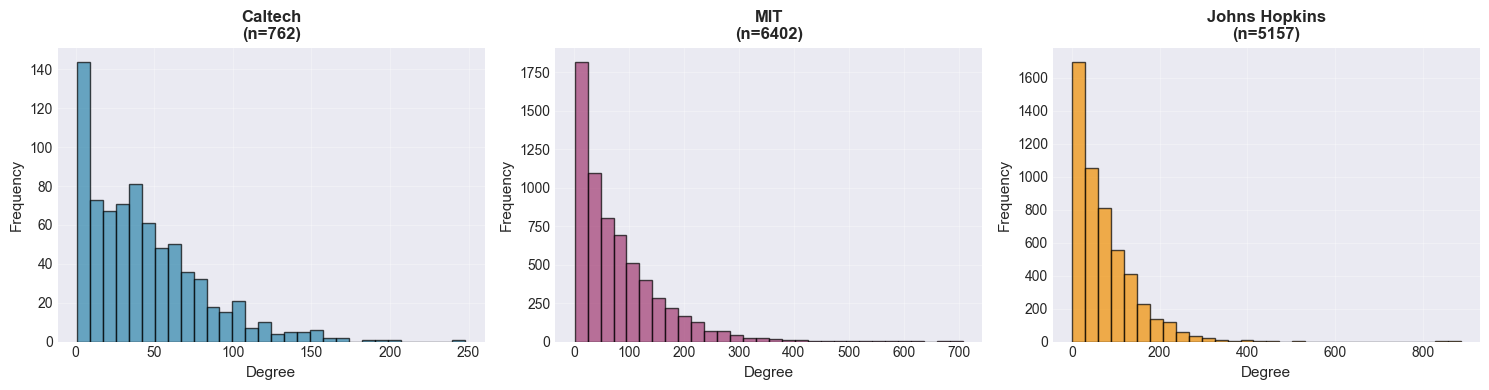

  ✓ Saved: ../results/figures/q2a_degree_distributions.png


In [14]:
#3: Degree distributions (Plot) 
print("\nGenerating degree distribution plots...")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#2E86AB', '#A23B72', '#F18F01']

for idx, (name, G) in enumerate(graphs.items()):
    degrees = [d for n, d in G.degree()]
    
    # Histogramme
    axes[idx].hist(degrees, bins=30, alpha=0.7, color=colors[idx], edgecolor='black')
    axes[idx].set_xlabel('Degree', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'{name}\n(n={G.number_of_nodes()})', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'q2a_degree_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {RESULTS_PATH / 'q2a_degree_distributions.png'}")


In [17]:
# 4. Analyse de la topologie : Spare vs Dense 
print("TOPOLOGY ANALYSIS")

for name, G in graphs.items():
    n = G.number_of_nodes()
    density = nx.density(G)
    max_possible_edges = n * (n - 1) / 2
    actual_edges = G.number_of_edges()
    sparsity = 1 - density
    
    print(f"\n{name}:")
    print(f"  Density: {density:.6f}")
    print(f"  Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
    print(f"  Actual edges: {actual_edges:,}")
    print(f"  Max possible edges: {int(max_possible_edges):,}")
    print(f"  → Network is SPARSE" if density < 0.1 else f"  → Network is DENSE")



TOPOLOGY ANALYSIS

Caltech:
  Density: 0.057429
  Sparsity: 0.9426 (94.26%)
  Actual edges: 16,651
  Max possible edges: 289,941
  → Network is SPARSE

MIT:
  Density: 0.012261
  Sparsity: 0.9877 (98.77%)
  Actual edges: 251,230
  Max possible edges: 20,489,601
  → Network is SPARSE

Johns Hopkins:
  Density: 0.014034
  Sparsity: 0.9860 (98.60%)
  Actual edges: 186,572
  Max possible edges: 13,294,746
  → Network is SPARSE



Generating degree vs clustering scatter plots...


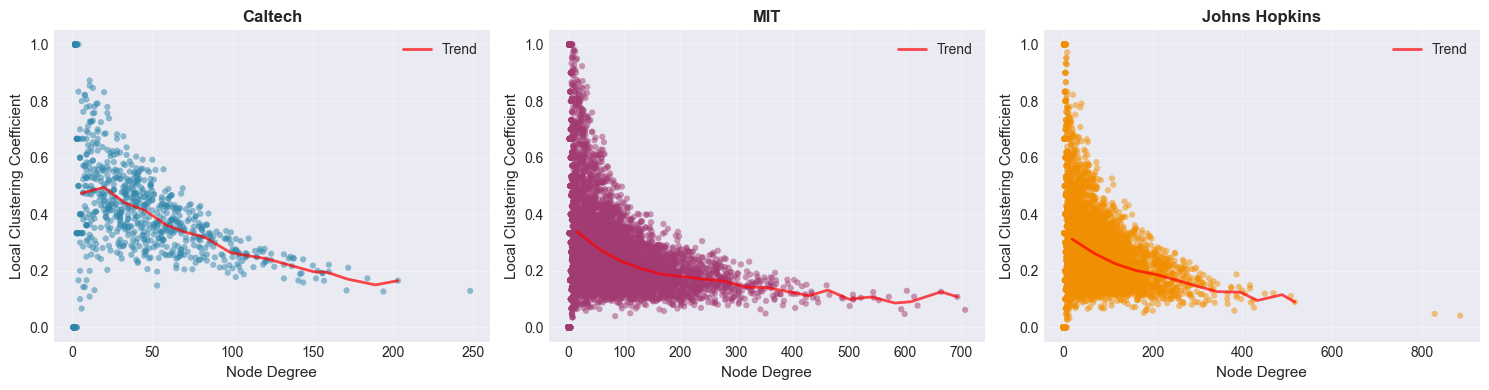

  ✓ Saved: ../results/figures/q2b_degree_vs_clustering.png


In [18]:
#5. Question 2b - DEGREE vs CLUSTERING SCATTER PLOTS 
print("\nGenerating degree vs clustering scatter plots...")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, G) in enumerate(graphs.items()):
    degrees = dict(G.degree())
    clustering = nx.clustering(G)
    
    # Extraire données
    x = [degrees[node] for node in G.nodes()]
    y = [clustering[node] for node in G.nodes()]
    
    # Scatter plot
    axes[idx].scatter(x, y, alpha=0.5, s=20, color=colors[idx], edgecolors='none')
    axes[idx].set_xlabel('Node Degree', fontsize=11)
    axes[idx].set_ylabel('Local Clustering Coefficient', fontsize=11)
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Moyenne par bin de degree (pour voir la tendance)
    if len(x) > 0:
        bins = np.linspace(min(x), max(x), 20)
        bin_indices = np.digitize(x, bins)
        bin_means_x = [np.mean([x[i] for i in range(len(x)) if bin_indices[i] == j]) 
                       for j in range(1, len(bins))]
        bin_means_y = [np.mean([y[i] for i in range(len(y)) if bin_indices[i] == j]) 
                       for j in range(1, len(bins))]
        axes[idx].plot(bin_means_x, bin_means_y, 'r-', linewidth=2, alpha=0.7, label='Trend')
        axes[idx].legend()

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'q2b_degree_vs_clustering.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {RESULTS_PATH / 'q2b_degree_vs_clustering.png'}")

DEGREE DISTRIBUTIONS:
- All three networks show right-skewed degree distributions
- Most nodes have relatively low degrees, with a long tail of high-degree nodes
- This is characteristic of social networks (scale-free-like behavior)

CLUSTERING:
- All networks have high clustering coefficients (>> random graphs)
- Caltech shows the highest clustering (small, tight-knit community)
- This indicates strong local community structure

SPARSITY:
- All networks are SPARSE (density < 1%)
- This is expected for large social networks
- Despite sparsity, high clustering indicates "small-world" properties

DEGREE vs CLUSTERING:
- Negative correlation: high-degree nodes tend to have lower clustering
- This is typical in social networks (hubs connect different communities)
- Low-degree nodes are often in tightly-knit local groups

DIFFERENCES BETWEEN NETWORKS:
- Caltech: Smaller, denser, higher clustering (tight community)
- MIT & Johns Hopkins: Larger, more diverse connection patterns
- All show similar qualitative patterns despite size differences

In [19]:
# Sauvegarder le tableau de stats
df_stats.to_csv(RESULTS_PATH.parent / 'q2_network_statistics.csv', index=False)